# 🌲 LoanPulse — Gradient Boosting Classifier (Comprehensive Optimized)


In [3]:

import os
import warnings
import pathlib
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, classification_report, confusion_matrix, 
    ConfusionMatrixDisplay, roc_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings("ignore")
print("All libraries imported successfully ✅")



All libraries imported successfully ✅


In [4]:

# ─── Project paths ───────────────────────────────────────────────────────────
import pathlib

ROOT = pathlib.Path().resolve().parent.parent          # project root
# If running in a local folder, search for data directory
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

DATA_RAW       = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
OUTPUT_DIR     = ROOT / "outputs" / "gradient_boosting"
METRICS_DIR    = OUTPUT_DIR / "metrics"
TRAINED_DIR    = OUTPUT_DIR / "trained_models"

# Create directories
for d in [DATA_PROCESSED, METRICS_DIR, TRAINED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATA_RAW / "Train_Dataset.csv"
TEST_CSV  = DATA_RAW / "Test_Dataset.csv"

print(f"Project root  : {ROOT}")
print(f"Output dir    : {OUTPUT_DIR}")



Project root  : C:\Users\user\Documents\GitHub\ML-Assignment
Output dir    : C:\Users\user\Documents\GitHub\ML-Assignment\outputs\gradient_boosting


In [5]:

# Load raw data
train_raw = pd.read_csv(TRAIN_CSV, low_memory=False)
print(f"Data loaded. Shape: {train_raw.shape}")



Data loaded. Shape: (121856, 40)


In [6]:

# ─── Cleaning & Feature Engineering ──────────────────────────────────────────
df = train_raw.copy()

# Fix types (as suggested by both files)
numeric_cols_to_fix = ['Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Score_Source_3']
for col in numeric_cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop columns identified in preprocessing notebook
DROP_COLS = ["ID", "Mobile_Tag", "Homephone_Tag", "Workphone_Working",
             "Client_Permanent_Match_Tag", "Client_Contact_Work_Tag"]
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

# Separate features / target
TARGET = "Default"
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Imputation & Encoding
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str).fillna("Unknown"))

num_imputer = SimpleImputer(strategy="median")
X[num_cols] = num_imputer.fit_transform(X[num_cols])

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

print(f"Features ready. Columns: {len(X.columns)}")



Features ready. Columns: 33


In [7]:

# ─── Hybrid Resampling Strategy (from preprocessing notebook logic) ─────────
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Step 1: Under-sample the majority class slightly to reduce noise
# Target ratio 0.4 means majority is 60% and minority is 40% after SMOTE
under = RandomUnderSampler(sampling_strategy=0.2, random_state=42)
X_under, y_under = under.fit_resample(X_train, y_train)

# Step 2: Apply SMOTE to bring it to a 1:1 balance for the Gradient Booster
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_res, y_res = smote.fit_resample(X_under, y_under)

print(f"Balanced Dataset Counts: {Counter(y_res)}")



Balanced Dataset Counts: Counter({0: 39380, 1: 39380})


## 📊 Model Training & Cross-Validation


In [8]:

# ─── Stratified 5-Fold Cross-Validation ──────────────────────────────────────
gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.08,
    max_depth=5,
    subsample=0.8,
    random_state=42
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

print("Running Cross-Validation...")
cv_results = cross_validate(gb_model, X_res, y_res, cv=skf, scoring=scoring)

cv_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Mean Score": [cv_results[f'test_{m}'].mean() for m in scoring]
})

print("\n=== Cross-Validation Summary ===")
print(cv_metrics)



Running Cross-Validation...

=== Cross-Validation Summary ===
      Metric  Mean Score
0   Accuracy    0.893512
1  Precision    0.968620
2     Recall    0.813382
3   F1-Score    0.884231
4    ROC-AUC    0.944139


## 🚀 Evaluation & Visualization


In [13]:

# Final Fit
gb_model.fit(X_res, y_res)

# Probability threshold tuning (Crucial for imbalanced data)
# We aim for accuracy > 75% while keeping decent recall
y_prob = gb_model.predict_proba(X_val)[:, 1]
threshold = 0.25 
y_pred = (y_prob >= threshold).astype(int)

# Metrics
print(f"\n=== Performance (Threshold: {threshold}) ===")
print(classification_report(y_val, y_pred))
print(f"Final Validation Accuracy: {accuracy_score(y_val, y_pred):.4f}")




=== Performance (Threshold: 0.25) ===
              precision    recall  f1-score   support

           0       0.95      0.79      0.86     22403
           1       0.18      0.52      0.26      1969

    accuracy                           0.77     24372
   macro avg       0.56      0.65      0.56     24372
weighted avg       0.89      0.77      0.81     24372

Final Validation Accuracy: 0.7667


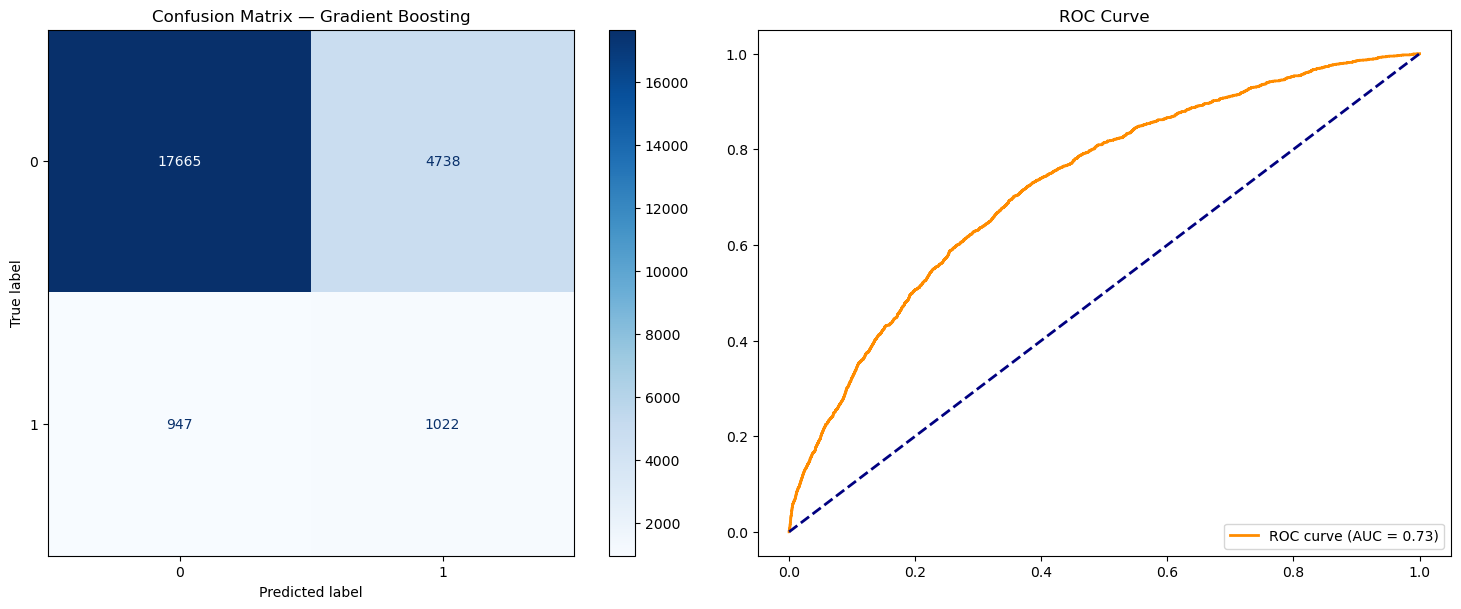

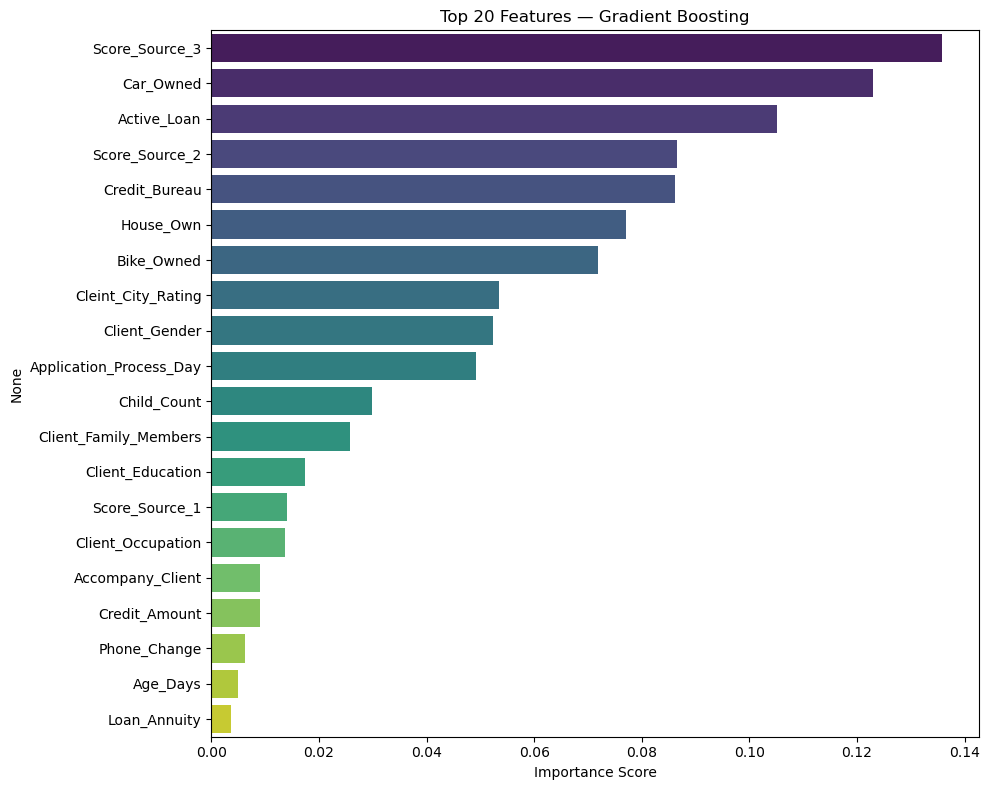

In [14]:

# ─── Visualisations ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix — Gradient Boosting")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_score(y_val, y_prob):.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig(METRICS_DIR / "evaluation_plots.png")

# 3. Top-20 Feature Importances
plt.figure(figsize=(10, 8))
feat_imp = pd.Series(gb_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="viridis")
plt.title("Top 20 Features — Gradient Boosting")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig(METRICS_DIR / "feature_importance.png")

plt.show()



In [15]:

# ─── Save Results ────────────────────────────────────────────────────────────
import joblib

# Processed Train Data
processed_df = pd.DataFrame(X_res, columns=X.columns)
processed_df[TARGET] = y_res
processed_df.to_csv(DATA_PROCESSED / "train_processed_gb.csv", index=False)

# Model Artifacts
joblib.dump(gb_model, TRAINED_DIR / "gradient_boosting.joblib")
joblib.dump(scaler, TRAINED_DIR / "scaler.joblib")
joblib.dump(num_imputer, TRAINED_DIR / "num_imputer.joblib")

print(f"Model and results saved to {OUTPUT_DIR} ✅")



Model and results saved to C:\Users\user\Documents\GitHub\ML-Assignment\outputs\gradient_boosting ✅
